In [11]:
# Manual data inspection
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("./output/nodelist_networkfeatures.csv")

## Symbolic regression is too narrow keyword
df_is_sr = df["keywords"].str.contains("Symbolic regression").astype(bool)
df_sr = df.loc[df_is_sr]
print("df_sr", len(df_sr))

## topic.id:t11975 Evolutionary Algorithms and Applications
df_is_evo = df["topic_ids"].str.contains("T11975")
df_evo = df.loc[df_is_evo]
print("df_evo", len(df_evo))

print(df.columns)

df_sr 120
df_evo 3959
Index(['id', 'published_year', 'work_type', 'institutions_distinct_count',
       'max_prev_year_author_citation', 'open_access', 'indexed_in',
       'language', 'len_display_name', 'is_review',
       'first_year_citation_count', 'ten_year_citation_count',
       'total_cited_by_count', 'error_status', 'referenced_works_count',
       'keywords', 'topic_ids', 'subfield_ids', 'field_ids', 'domain_ids',
       'indegree', 'outdegree', 'cd_index', 'n_I', 'n_J', 'n_K', 'pagerank',
       'hub_score', 'authority_score', 'clustering_coefficient'],
      dtype='object')


### Disclosure : Biases were imposed by sampling...

These biases were not strictly handled.

<Axes: title={'center': 'Publish year bias induced by reference backtracking'}, ylabel='Frequency'>

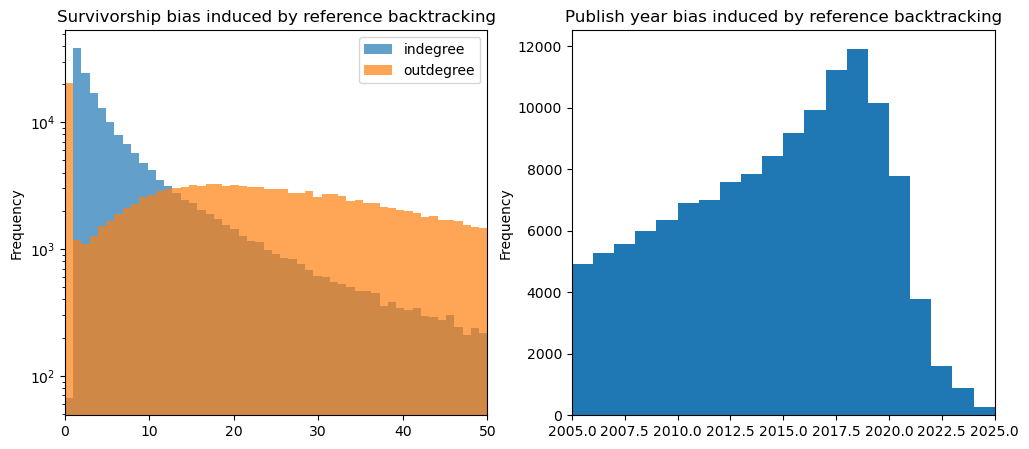

In [13]:
# Biases imposed by sampling
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df[["indegree","outdegree"]].plot.hist(bins=np.linspace(0,50,52),xlim=[0,50], logy=True, alpha=0.7, title="Survivorship bias induced by reference backtracking", ax=axes[0])
df["published_year"].plot.hist(bins=np.linspace(2005,2025,21),xlim=[2005,2025], title="Publish year bias induced by reference backtracking", ax=axes[1])

### Consolidating atmosphere of Evo. Algo. field

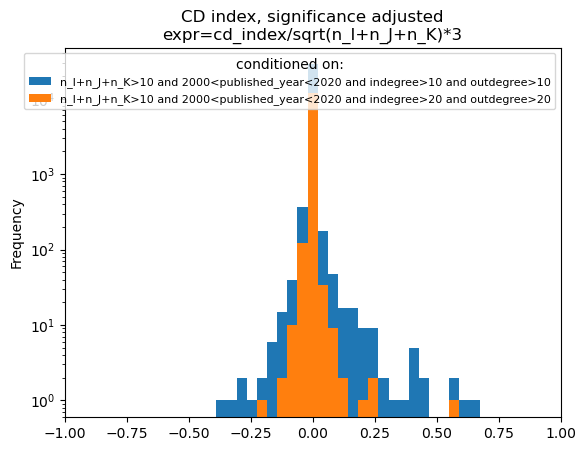

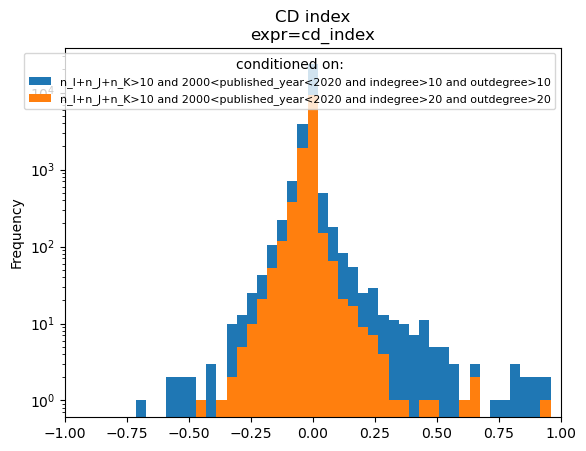

In [14]:
control = ["indegree>10 and outdegree>10", "indegree>20 and outdegree>20"]
control = ["n_I+n_J+n_K>10 and 2000<published_year<2020 and "+c for c in control]

expr = "cd_index/sqrt(n_I+n_J+n_K)*3"
dfs = {c:df.query(c).eval(expr).clip(-1,1) for c in control}
pd.DataFrame(dfs).plot.hist(bins=np.linspace(-1,1,50), logy=True, xlim=[-1,1], title=f"CD index, significance adjusted\nexpr={expr}")
legend = plt.legend(title="conditioned on:", fontsize="8")

expr = "cd_index"
dfs = {c:df.query(c).eval(expr).clip(-1,1) for c in control}
pd.DataFrame(dfs).plot.hist(bins=np.linspace(-1,1,50), logy=True, xlim=[-1,1], title=f"CD index\nexpr={expr}")
legend = plt.legend(title="conditioned on:", fontsize="8")

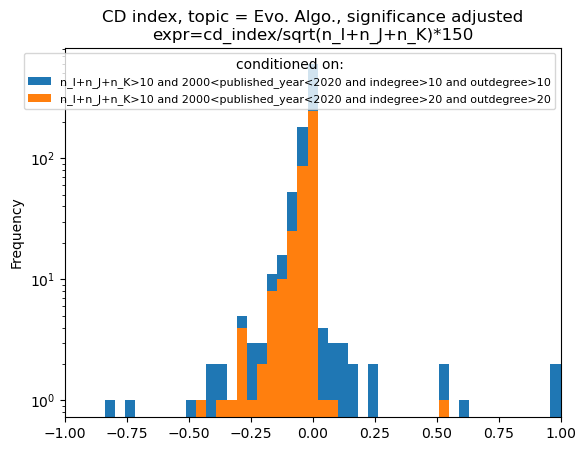

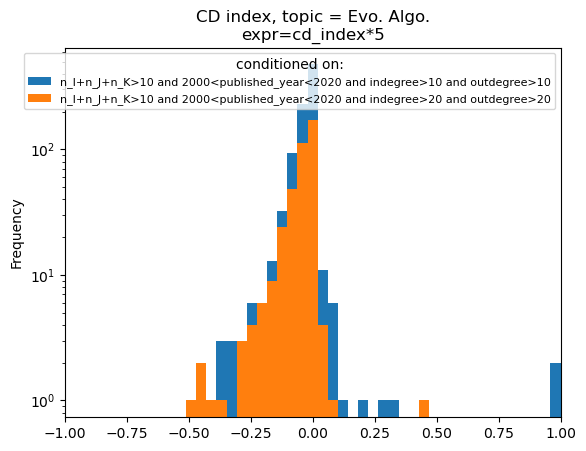

In [15]:
control = ["indegree>10 and outdegree>10", "indegree>20 and outdegree>20"]
control = ["n_I+n_J+n_K>10 and 2000<published_year<2020 and "+c for c in control]

expr = "cd_index/sqrt(n_I+n_J+n_K)*150"
dfs = {c:df_evo.query("n_I+n_J+n_K>10").query(c).eval(expr).clip(-1,1) for c in control}
pd.DataFrame(dfs).plot.hist(bins=np.linspace(-1,1,50), logy=True, xlim=[-1,1], title=f"CD index, topic = Evo. Algo., significance adjusted\nexpr={expr}")
legend = plt.legend(title="conditioned on:", fontsize="8")

expr = "cd_index*5"
dfs = {c:df_evo.query("n_I+n_J+n_K>10").query(c).eval(expr).clip(-1,1) for c in control}
pd.DataFrame(dfs).plot.hist(bins=np.linspace(-1,1,50), logy=True, xlim=[-1,1], title=f"CD index, topic = Evo. Algo.\nexpr={expr}")
legend = plt.legend(title="conditioned on:", fontsize="8")

### Two factors : disruptiveness, centrality 

the result is aligned with previous research

In [16]:
df_ = df
df_.loc[:,"pub_yr_clip_10"] = df_.eval('2026-published_year').clip(3,10)
exprs = {
    "rnk_disruptive": "cd_index/sqrt(n_I+n_J+n_K)", 
    "rnk_impact_lt": "ten_year_citation_count / pub_yr_clip_10",
    "rnk_impact_st": "first_year_citation_count",
    "rnk_pagerank": "pagerank",
    # "open_access": "open_access",
}
control = "n_I+n_J+n_K>10 and 2000<published_year<2020"
df_scores = pd.DataFrame({
    k: df_.query(control).eval(v).rank(pct=True)
    for k,v in exprs.items()
})

df_scores.corr().style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,rnk_disruptive,rnk_impact_lt,rnk_impact_st,rnk_pagerank
rnk_disruptive,1.00,-0.09,-0.03,-0.19
rnk_impact_lt,-0.09,1.00,0.42,0.43
rnk_impact_st,-0.03,0.42,1.00,0.05
rnk_pagerank,-0.19,0.43,0.05,1.00


In [17]:
df_ = df_evo
df_.loc[:,"pub_yr_clip_10"] = df_.eval('2026-published_year').clip(3,10)
exprs = {
    "rnk_disruptive": "cd_index/sqrt(n_I+n_J+n_K)", 
    "rnk_impact_lt": "ten_year_citation_count / pub_yr_clip_10",
    "rnk_impact_st": "first_year_citation_count",
    "rnk_pagerank": "pagerank",
    # "open_access": "open_access",
}
control = "n_I+n_J+n_K>10 and 2000<published_year<2020"
df_scores = pd.DataFrame({
    k: df_.query(control).eval(v).rank(pct=True)
    for k,v in exprs.items()
})

df_scores.corr().style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

/tmp/nix-shell-126861-2568667819/ipykernel_146231/3592956683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_.loc[:,"pub_yr_clip_10"] = df_.eval('2026-published_year').clip(3,10)


,rnk_disruptive,rnk_impact_lt,rnk_impact_st,rnk_pagerank
rnk_disruptive,1.00,-0.16,-0.01,-0.28
rnk_impact_lt,-0.16,1.00,0.38,0.52
rnk_impact_st,-0.01,0.38,1.00,0.01
rnk_pagerank,-0.28,0.52,0.01,1.00


### Different flavors of keywords

* Centrality prefers 

In [18]:
# top 10 disruptive papers in SR(Evo. Algo)
df_top10_disr = df_evo.loc[df_scores["rnk_disruptive"].sort_values().iloc[::-1].index].iloc[:10]
topics_disr = pd.DataFrame([x.split("::") for x in "|".join(df_top10_disr["keywords"].tolist()).split("|")]).set_index(0)[1].astype(float).groupby(0).sum().sort_values(ascending=False)
pd.options.display.max_rows = 999
print(topics_disr)
df_top10_disr.T

0
Computer science                        5.502
Artificial intelligence                 3.660
Evolutionary computation                3.240
Computation                             2.057
Algorithm                               1.682
Evolutionary algorithm                  1.490
Field (mathematics)                     1.362
Genetic representation                  1.113
Genetic algorithm                       0.947
Stigmergy                               0.839
Data science                            0.789
Swarm robotics                          0.787
Swarm intelligence                      0.768
Management science                      0.762
Genetic programming                     0.737
Soft computing                          0.725
Mathematics                             0.718
Feature selection                       0.704
Operations research                     0.663
Swarm behaviour                         0.648
Session (web analytics)                 0.642
Estimation of distribution algor

,7398,131163,89481,23873,174932,62029,127911,51196,150742,153501
id,https://openalex.org/W1666784313,https://openalex.org/W3002534707,https://openalex.org/W82518839,https://openalex.org/W4297922645,https://openalex.org/W1551103807,https://openalex.org/W4300610723,https://openalex.org/W4293860453,https://openalex.org/W4301762632,https://openalex.org/W1504391786,https://openalex.org/W2251503907
published_year,2008,2009,2006,2006,2002,2014,2006,2017,2008,2015
work_type,book,article,book,book-chapter,book,paratext,article,paratext,book,paratext
institutions_distinct_count,2,3,4,1,1,0,0,0,1,0
max_prev_year_author_citation,0,0,0,0,0,0,0,0,0,0
open_access,True,False,False,False,False,False,False,False,False,False
indexed_in,NaN,NaN,NaN,crossref,crossref,crossref,crossref,crossref,crossref,crossref
language,en,en,en,en,en,en,en,en,en,en
len_display_name,49,64,131,55,67,52,41,66,34,81
is_review,0,0,0,0,0,0,0,0,0,0


In [19]:
# top 10 pagerank papers in SR(Evo. Algo)
df_top10_pr = df_evo.loc[df_scores["rnk_pagerank"].sort_values().iloc[::-1].index].iloc[:10]
topics_pr = pd.DataFrame([x.split("::") for x in "|".join(df_top10_pr["keywords"].tolist()).split("|")]).set_index(0)[1].astype(float).groupby(0).sum().sort_values(ascending=False)
pd.options.display.max_rows = 999
print(topics_pr)
df_top10_pr.T

0
Computer science                      4.937
Particle swarm optimization           4.049
Mathematical optimization             3.868
Algorithm                             3.123
Mathematics                           2.681
Swarm behaviour                       2.594
Evolutionary algorithm                2.380
Artificial intelligence               2.303
Multi-swarm optimization              2.153
Population                            1.990
Genetic algorithm                     1.336
Evolutionary computation              1.312
Swarm intelligence                    1.133
Convergence (economics)               1.093
Metaheuristic                         1.001
Computation                           0.903
Machine learning                      0.827
Artificial bee colony algorithm       0.824
Sorting                               0.754
Binary number                         0.732
Reinforcement learning                0.722
Honey bee                             0.721
Benchmark (surveying)         

,73785,9559,100048,22254,132225,3517,24849,28942,97014,118642
id,https://openalex.org/W2121863487,https://openalex.org/W2126105956,https://openalex.org/W2109364787,https://openalex.org/W2165299997,https://openalex.org/W2169245194,https://openalex.org/W2125213524,https://openalex.org/W2143560894,https://openalex.org/W2287814884,https://openalex.org/W2072955302,https://openalex.org/W2061438946
published_year,2005,2002,2002,2002,2002,2002,2007,2005,2009,2014
work_type,article,article,article,article,article,article,article,article,article,article
institutions_distinct_count,0,4,2,2,2,2,2,1,3,3
max_prev_year_author_citation,0,0,0,0,0,0,0,0,0,57
open_access,False,False,False,False,False,False,False,False,False,True
indexed_in,crossref,crossref,crossref,crossref,crossref,crossref,crossref,NaN,crossref,crossref
language,en,en,en,en,en,en,en,en,en,en
len_display_name,39,60,43,35,94,57,109,59,37,19
is_review,0,0,0,0,0,0,0,0,0,0


In [20]:
# top 10 (disruptive - pagerank) papers
df_top10_disr_pr = df_evo.loc[(df_scores["rnk_disruptive"] - df_scores["rnk_pagerank"]).sort_values().iloc[::-1].index].iloc[:10]
topics_disr_pr = pd.DataFrame([x.split("::") for x in "|".join(df_top10_disr_pr["keywords"].tolist()).split("|")]).set_index(0)[1].astype(float).groupby(0).sum().sort_values(ascending=False)
pd.options.display.max_rows = 999
print(topics_disr_pr)
df_top10_disr_pr.T

0
Computer science                               6.558
Artificial intelligence                        3.682
Algorithm                                      2.081
Machine learning                               2.010
Crossover                                      1.968
Genetic algorithm                              1.727
Reinforcement learning                         1.642
Representation (politics)                      1.323
Artificial neural network                      1.220
Fitness function                               1.059
Deixis                                         0.955
Mathematics                                    0.932
Mathematical optimization                      0.884
Data mining                                    0.879
Neuroevolution                                 0.871
Feature selection                              0.819
Metaheuristic                                  0.760
Generalization                                 0.734
Benchmark (surveying)                       

,142230,122540,65579,79775,109826,25606,123934,123744,19182,60003
id,https://openalex.org/W2029648049,https://openalex.org/W2953260400,https://openalex.org/W4302417998,https://openalex.org/W1217149292,https://openalex.org/W1604541444,https://openalex.org/W2769303158,https://openalex.org/W2885208939,https://openalex.org/W1502369731,https://openalex.org/W2134285985,https://openalex.org/W1976384541
published_year,2006,2012,2010,2012,2005,2017,2018,2002,2006,2008
work_type,article,preprint,book-chapter,book-chapter,article,article,article,article,article,article
institutions_distinct_count,4,4,4,1,3,4,3,2,4,4
max_prev_year_author_citation,0,0,0,0,0,0,1,0,0,0
open_access,False,True,False,False,False,False,False,False,False,False
indexed_in,crossref,arxiv,crossref,crossref,crossref,crossref,crossref,crossref,crossref,crossref
language,en,NaN,en,en,en,en,en,en,en,en
len_display_name,68,98,26,78,68,93,77,69,91,68
is_review,0,0,0,0,0,0,0,0,0,0


In [21]:
# common_topics = set(topics_disr.rank(pct=True).index).intersection(topics_pr.rank(pct=True).index)#.intersection(topics_disr_pr.index)
# pd.Series({k: (topics_disr[k] - topics_pr[k]).round(2) for k in common_topics}).sort_values()

common_topics = set(topics_disr_pr.rank(pct=True).index).intersection(topics_pr.rank(pct=True).index)#.intersection(topics_disr_pr.index)
pd.Series({k: (topics_disr_pr[k] - topics_pr[k]).round(2) for k in common_topics}).sort_values()

Mathematical optimization       -2.98
Mathematics                     -1.75
Algorithm                       -1.04
Metaheuristic                   -0.24
Engineering                     -0.15
Benchmark (surveying)            0.01
Selection (genetic algorithm)    0.06
Reinforcement                    0.06
Task (project management)        0.16
Genetic algorithm                0.39
Artificial neural network        0.67
Reinforcement learning           0.92
Machine learning                 1.18
Crossover                        1.31
Artificial intelligence          1.38
Computer science                 1.62
dtype: float64